Тема 1. Моделирование геометрической вероятности
Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.


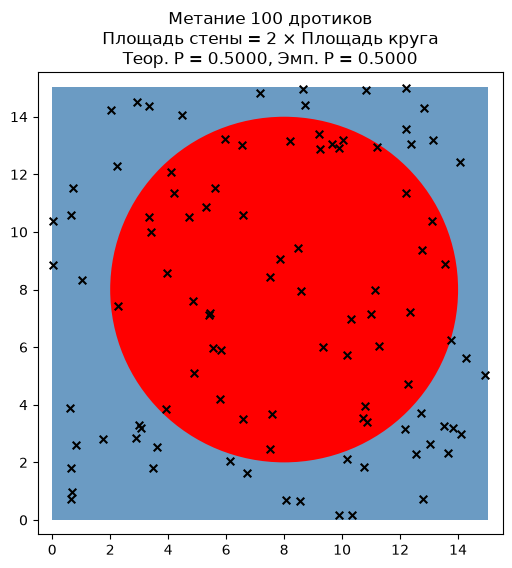

В красный круг из 100 дротиков попало 50.
Доля попавших составила 0.5000
Теоретическая вероятность: 0.5000 (50%)
Отклонение: 0.00%


In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np

def darts(size):
    # Радиус круга
    R = 6
    # Центр круга (в центре стены)
    x0, y0 = 8, 8
    
    # Площадь круга
    S_circle = np.pi * R**2
    # Площадь стены = 2 * площадь круга
    S_wall = 2 * S_circle
    # Сторона квадратной стены
    side = np.sqrt(S_wall)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax = plt.gca()
    
    # Рисуем стену (синий прямоугольник)
    ax.add_patch(Rectangle((0, 0), side, side, facecolor='steelblue', alpha=0.8))
    
    # Рисуем круг (красный)
    ax.add_patch(Circle((x0, y0), R, facecolor='red'))
    
    # Генерируем случайные координаты дротиков
    X = np.random.uniform(0, side, size)
    Y = np.random.uniform(0, side, size)
    
    # Отображаем дротики
    plt.scatter(X, Y, marker='x', c='black', s=30)
    
    # Подсчитаем попавшие в круг
    inside = len([d for d in range(size) if (X[d] - x0)**2 + (Y[d] - y0)**2 <= R**2])
    
    # Эмпирическая вероятность
    prob = inside / size
    
    # Теоретическая вероятность
    theor_prob = S_circle / S_wall
    
    plt.xlim(-0.5, side + 0.5)
    plt.ylim(-0.5, side + 0.5)
    plt.title(f'Метание {size} дротиков\n'
              f'Площадь стены = 2 × Площадь круга\n'
              f'Теор. P = {theor_prob:.4f}, Эмп. P = {prob:.4f}')
    plt.show()
    
    print(f'В красный круг из {size} дротиков попало {inside}.')
    print(f'Доля попавших составила {prob:.4f}')
    print(f'Теоретическая вероятность: {theor_prob:.4f} (50%)')
    print(f'Отклонение: {abs(prob - theor_prob)*100:.2f}%')

# Запуск симуляции
darts(100)

Круглая мишень радиусом R = 20 см разделена на концентрические зоны:
* Яблочко — центральный круг радиусом r₁ = 2 см
* Кольцо 1 — область между окружностями радиусов r₁ = 2 см и r₂ = 6 см
* Кольцо 2 — область между окружностями радиусов r₂ = 6 см и r = 12 см
* Кольцо 3 — область между окружностью радиуса r₃ = 12 см и краем мишени (R = 20 см)

Игрок бросает дротик в мишень. Предполагается, что дротик гарантированно попадает в мишень, и вероятность попадания в любую точку мишени одинакова (равномерное распределение).

### Найти вероятность, что дротик попадёт:
* в центр мишени
* в кольцо 1
* в кольцо 2
* в кольцо 3

In [31]:
# Для ползунков, их дробных значений, контейнер для вертикального расположения, их целых значений
from ipywidgets import interactive_output, FloatSlider, VBox, IntSlider
# отображение виджетов
from IPython.display import display
# Для построения графиков
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
# матем операции
import numpy as np

# Исходные данные (по умолчанию)
R = 20      # радиус мишени (см)
r1 = 2      # радиус яблочка (см)
r2 = 6      # внешний радиус кольца 1 (см)
r3 = 12     # внешний радиус кольца 2 (см)
angle = 60  # угол сектора (градусы)

# Ползунки для параметров (continuous_update=False - обновление графиков после отпускания ползунка)
slider_R = IntSlider(value=20, min=10, max=30, step=1, 
                     description='Радиус мишени R (см):', continuous_update=False)
slider_r1 = IntSlider(value=2, min=1, max=5, step=1, 
                      description='Радиус яблочка r₁ (см):', continuous_update=False)
slider_r2 = IntSlider(value=6, min=3, max=15, step=1, 
                      description='Внешний радиус кольца 1 r₂ (см):', continuous_update=False)
slider_r3 = IntSlider(value=12, min=5, max=25, step=1, 
                      description='Внешний радиус кольца 2 r₃ (см):', continuous_update=False)
slider_angle = IntSlider(value=60, min=10, max=180, step=10, 
                         description='Угол сектора (°):', continuous_update=False)

# Функция построения графика и вычисления вероятностей
def darts(R, r1, r2, r3):
    # Вычисление площадей зон
    S_total = np.pi * R**2          # общая площадь мишени
    S_bullseye = np.pi * r1**2      # площадь яблочка
    S_ring1 = np.pi * (r2**2 - r1**2)  # площадь кольца 1
    S_ring2 = np.pi * (r3**2 - r2**2)  # площадь кольца 2
    S_ring3 = np.pi * (R**2 - r3**2)   # площадь кольца 3
    
    # Вычисление вероятностей
    P_bullseye = S_bullseye / S_total
    P_ring1 = S_ring1 / S_total
    P_ring2 = S_ring2 / S_total
    P_ring3 = S_ring3 / S_total
    
    # Создаем график
    fig, ax1 = plt.subplots(figsize=(16, 7))
    
    # Рисуем кольца (от внешнего к внутреннему)
    circle4 = Circle((0, 0), R, facecolor='lightgreen', edgecolor='black', linewidth=2, alpha=0.7)
    circle3 = Circle((0, 0), r3, facecolor='yellow', edgecolor='black', linewidth=2, alpha=0.7)
    circle2 = Circle((0, 0), r2, facecolor='orange', edgecolor='black', linewidth=2, alpha=0.7)
    circle1 = Circle((0, 0), r1, facecolor='red', edgecolor='black', linewidth=2, alpha=0.7)
    
    ax1.add_patch(circle4)
    ax1.add_patch(circle3)
    ax1.add_patch(circle2)
    ax1.add_patch(circle1)
    
    # Подписи зон
    ax1.text(0, 0, f'Яблочко\n{P_bullseye*100:.1f}%', ha='center', va='center', 
             fontsize=9, fontweight='bold', color='white')
    ax1.text(0, (r1 + r2)/2, f'Кольцо 1\n{P_ring1*100:.1f}%', ha='center', va='center', 
             fontsize=9, fontweight='bold')
    ax1.text(0, (r2 + r3)/2, f'Кольцо 2\n{P_ring2*100:.1f}%', ha='center', va='center', 
             fontsize=9, fontweight='bold')
    ax1.text(0, (r3 + R)/2, f'Кольцо 3\n{P_ring3*100:.1f}%', ha='center', va='center', 
             fontsize=9, fontweight='bold')
    
    ax1.set_xlim(-R-1, R+1)
    ax1.set_ylim(-R-1, R+1)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X (см)', fontsize=11)
    ax1.set_ylabel('Y (см)', fontsize=11)
    ax1.set_title('Мишень для дротиков', fontsize=13, fontweight='bold')
    
    # Добавляем текстовое поле с результатами
    textstr = (f'Площадь мишени: {S_total:.1f} см²\n'
               f'Яблочко: {S_bullseye:.1f} см² ({P_bullseye*100:.1f}%)\n'
               f'Кольцо 1: {S_ring1:.1f} см² ({P_ring1*100:.1f}%)\n'
               f'Кольцо 2: {S_ring2:.1f} см² ({P_ring2*100:.1f}%)\n'
               f'Кольцо 3: {S_ring3:.1f} см² ({P_ring3*100:.1f}%)\n' )
    
    plt.tight_layout()
    plt.show()

# Создаем интерактивный вывод
# создаёт объект, который автоматически вызывает построение графика после изменения ползунков
# создаём словарь: параметры ф-ции -> виджет
# когда двигаем ползунок - передаем значение в параметр ф-ции
out = interactive_output(darts, {
    'R': slider_R,
    'r1': slider_r1,
    'r2': slider_r2,
    'r3': slider_r3,
})

# Отображаем
display(VBox([slider_R, slider_r1, slider_r2, slider_r3, out]))

Студент добирается до факультета с пересадкой. Сначала он ждет на остановке трамвай, затем на другой остановке ждет автобус. Интервал движения трамвая составляет 12   минут, интервал движения автобуса — 8   минут. Найти вероятность того, что студенту придется ждать на остановках в сумме не более 10   минут.

### Площадь пространства исходов

Пространство $\Omega$ — прямоугольник со сторонами $12$ и $8$:

$$S_{\Omega} = T_{\text{трамвай}} \times T_{\text{автобус}} = 12 \times 8 = 96 \text{ мин}^2$$

### Область благоприятных исходов

Благоприятная область: $x + y \leq 10$ внутри $\Omega$.

Найдём точки пересечения прямой $x + y = 10$ с границами прямоугольника:

$$
\begin{cases}
y = 0 \Rightarrow x = 10 &\rightarrow \text{точка } (10; 0) \\
y \leq 8 &\rightarrow \text{при } y = 8: x = 2 \rightarrow \text{точка } (2; 8)
\end{cases}
$$

Область $A$ — **трапеция** с вершинами:
$$(0; 0), \quad (10; 0), \quad (2; 8), \quad (0; 8)$$

### Площадь благоприятной области

Трапеция имеет:
- Нижнее основание: $a = 10$
- Верхнее основание: $b = 2$
- Высота: $h = 8$

$$S_A = \frac{a + b}{2} \cdot h = \frac{10 + 2}{2} \cdot 8 = 48 \text{ мин}^2$$

### Вероятность

$$P(A) = \frac{S_A}{S_{\Omega}} = \frac{48}{96} = \frac{1}{2} = 0.5$$

In [ ]:
# Для ползунков, их дробных значений, контейнер для вертикального расположения, их целых знач
from ipywidgets import interactive_output, FloatSlider, VBox, IntSlider
# отображение виджетов
from IPython.display import display
# Для посторения графиков
import matplotlib.pyplot as plt
# матем операции
import numpy as np

T_tram = 12   # интервал трамвая (мин)
T_bus = 8     # интервал автобуса (мин)
T_max = 10    # максимально допустимое суммарное время ожидания (мин)


# Ползунки для параметров (continuous_update=False - обновление графиков после отпускания ползунка)
tram_interval = IntSlider(value=12, min=5, max=20, step=1, 
                          description='Трамвай (мин):', continuous_update=False)
bus_interval = IntSlider(value=8, min=3, max=15, step=1, 
                         description='Автобус (мин):', continuous_update=False)
max_wait = FloatSlider(value=10.0, min=1.0, max=20.0, step=0.5, 
                       description='Макс. ожидание:', continuous_update=False)

# график
def S(T_tram, T_bus, T_max):   
    # Вычисление вероятности
    S_omega = T_tram * T_bus
    
    # Находим точки пересечения
    # если макс_сум <= вр_авт, то будет не трапеция, а треугольник
    if T_max <= T_bus:
        x = T_max
        y = 0
        S_A = 0.5 * T_max * T_max
    # если если макс_сум >= вр_авт, то будет трапеция
    elif T_max <= T_tram:
        x = T_max
        y = 0
        S_A = 0.5 * T_bus * (2 * T_max - T_bus)
    else:
        if T_max - T_bus <= T_tram:
            # из общей площади вычетаем отсекаемый прямоугольный треугольник
            S_A = T_tram * T_bus - 0.5 * (T_tram + T_bus - T_max)**2
        else:
            S_A = T_tram * T_bus
    
    # отношение удовлет площади к основ площади ожидания времени
    P = S_A / S_omega
    
    # Создаем график 10 x 7 дюймов
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Прямоугольник пространства исходов
    # закрашивает светло-серым пространство по координатам замкнутого контура
    # прозрачность = 70%, черная рамка толщеной 2 пикселя
    # [лев_нижн_угол, прав_нижн_уг, прав_верх_уг, лев_верх_уг, точка замыкания]
    rect_x = [0, T_tram, T_tram, 0, 0]
    rect_y = [0, 0, T_bus, T_bus, 0]
    ax.fill(rect_x, rect_y, 'lightgray', alpha=0.7, edgecolor='black', linewidth=2)
    
    # Благоприятная область
    if T_max <= min(T_tram, T_bus):
        # Треугольник
        fav_x = [0, T_max, 0, 0]
        fav_y = [0, 0, T_max, 0]
        ax.plot([T_max, 0], [0, T_max], 'b--', linewidth=2, label=f'$x + y = {T_max}$')
    else:
        # Трапеция
        x2 = max(0, T_max - T_bus)
        x1 = min(T_max, T_tram)
        fav_x = [0, x1, x2, 0, 0]
        fav_y = [0, 0, T_bus, T_bus, 0]
        ax.plot([x1, x2], [0, T_bus], 'b--', linewidth=2, label=f'$x + y = {T_max}$')
    
    ax.fill(fav_x, fav_y, 'lightgreen', alpha=0.7, edgecolor='green', linewidth=2)
    
        
    # # Линия x + y = T_max
    
    # # создаём 100 точек от 0 до конца зелёной площади
    # x_line = np.linspace(0, min(T_tram, T_max), 100)
    # # ограничиваем сверху зелёную площадь
    # y_line = np.minimum(T_bus, T_max - x_line)
    
    # уст пределы с отступами 0.5
    ax.set_xlim(-0.5, T_tram + 0.5)
    ax.set_ylim(-0.5, T_bus + 0.5)
    # подписываем оси
    ax.set_xlabel('Время ожидания трамвая $X$ (мин)', fontsize=11)
    ax.set_ylabel('Время ожидания автобуса $Y$ (мин)', fontsize=11)
    # заголовок графика
    ax.set_title(f'Геометрическая вероятность\n'
                 r'$P(X + Y \leq %.1f) = %.4f$' % (T_max, P), 
                 fontsize=13, fontweight='bold')
    # сетка с 30% прозрачности
    ax.grid(True, alpha=0.3)
    # подключаем легенду
    ax.legend()
    
    # Добавляем текст с результатом
    textstr = f'Площадь Ω: {S_omega} мин²\nПлощадь A: {S_A:.1f} мин²\nВероятность: {P:.4f} ({P*100:.1f}%)'
    # текст размещён в левом верхнем углу, текст, фиксация на указанных координатах,
    # размер шрифта = 10, текст привязан к y=1, 
    # создаём рамку (скруглен углы, пшеничный фон, 80% прозрачность)
    ax.text(0, 1, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # оптимизация расположения эл-ов и показ графика
    plt.tight_layout()
    plt.show()

# Создаем интерактивный вывод
# создаёт объект, который автоматически вызывает построение графика после изменения ползунков
# создаём словарь: параметры ф-ции -> виджет
# когда двигаем ползунок - передаем значение в парамет ф-ции
out = interactive_output(S, {
    'T_tram': tram_interval,
    'T_bus': bus_interval,
    'T_max': max_wait
})

# Отображаем
display(VBox([tram_interval, bus_interval, max_wait, out]))